In [1]:
!pip install streamlit scikit-learn pandas numpy joblib

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

# Load the Diabetes dataset
diabetes = load_diabetes(as_frame=True)

# Convert to DataFrame
df = diabetes.frame

# Display first 5 rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print("Dataset Shape:", df.shape)
print("Features:", list(df.drop(columns="target").columns))
print("Target: target")

Dataset Shape: (442, 11)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: target


In [4]:
# Separate input features and target

X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
linear_r2 = r2_score(y_test, y_pred_linear)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

# Display results
print("Linear Regression - Baseline Model")
print("-----------------------------------")
print("R² Score :", round(linear_r2, 4))
print("MAE      :", round(linear_mae, 4))
print("RMSE     :", round(linear_rmse, 4))

Linear Regression - Baseline Model
-----------------------------------
R² Score : 0.4526
MAE      : 42.7941
RMSE     : 53.8534


In [7]:
from sklearn.linear_model import Lasso, Ridge

# Create models
lasso_model = Lasso()
ridge_model = Ridge()

# Train models
lasso_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

# Lasso metrics
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Ridge metrics
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Lasso Regression")
print("----------------")
print("R² Score :", round(lasso_r2, 4))
print("MAE      :", round(lasso_mae, 4))
print("RMSE     :", round(lasso_rmse, 4))

print("\nRidge Regression")
print("----------------")
print("R² Score :", round(ridge_r2, 4))
print("MAE      :", round(ridge_mae, 4))
print("RMSE     :", round(ridge_rmse, 4))

Lasso Regression
----------------
R² Score : 0.3576
MAE      : 49.7303
RMSE     : 58.3402

Ridge Regression
----------------
R² Score : 0.4192
MAE      : 46.1389
RMSE     : 55.4745


In [8]:
before_tuning = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso",
        "Ridge"
    ],
    "R² Score": [
        linear_r2,
        lasso_r2,
        ridge_r2
    ],
    "MAE": [
        linear_mae,
        lasso_mae,
        ridge_mae
    ],
    "RMSE": [
        linear_rmse,
        lasso_rmse,
        ridge_rmse
    ]
})

before_tuning["R² Percentage"] = (
    before_tuning["R² Score"] * 100
).round(2).astype(str) + "%"

before_tuning

,Model,R² Score,MAE,RMSE,R² Percentage
0,Linear Regression,0.452603,42.794095,53.853446,45.26%
1,Lasso,0.357592,49.730328,58.340172,35.76%
2,Ridge,0.419153,46.138858,55.474462,41.92%


In [9]:
from sklearn.model_selection import GridSearchCV

# -----------------------------
# Lasso Hyperparameter Tuning
# -----------------------------

lasso = Lasso()

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10]
}

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_


# -----------------------------
# Ridge Hyperparameter Tuning
# -----------------------------

ridge = Ridge()

ridge_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10]
}

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_


# -----------------------------
# Display Best Parameters
# -----------------------------

print("Best Lasso Alpha:", lasso_grid.best_params_)
print("Best Ridge Alpha:", ridge_grid.best_params_)

Best Lasso Alpha: {'alpha': 0.1}
Best Ridge Alpha: {'alpha': 0.1}


In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# =====================================================
# RANDOM FOREST — HYPERPARAMETER TUNING
# =====================================================

rf = RandomForestRegressor(
    random_state=42
)

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_


# =====================================================
# GRADIENT BOOSTING — HYPERPARAMETER TUNING
# =====================================================

gb = GradientBoostingRegressor(
    random_state=42
)

gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_


# =====================================================
# DISPLAY BEST PARAMETERS
# =====================================================

print("🌲 Random Forest")
print("Best Parameters:")
print(rf_grid.best_params_)

print("\n🚀 Gradient Boosting")
print("Best Parameters:")
print(gb_grid.best_params_)

🌲 Random Forest
Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🚀 Gradient Boosting
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}


In [11]:
# =====================================================
# STEP 9 — EVALUATE ALL MODELS
# =====================================================

# Predictions from tuned models

y_pred_lasso_tuned = best_lasso.predict(X_test)
y_pred_ridge_tuned = best_ridge.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_gb_tuned = best_gb.predict(X_test)


# =====================================================
# CALCULATE METRICS
# =====================================================

models = {
    "Linear Regression": y_pred_linear,
    "Lasso (Tuned)": y_pred_lasso_tuned,
    "Ridge (Tuned)": y_pred_ridge_tuned,
    "Random Forest (Tuned)": y_pred_rf_tuned,
    "Gradient Boosting (Tuned)": y_pred_gb_tuned
}


results = []

for model_name, predictions in models.items():

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results.append({
        "Model": model_name,
        "R² Score": r2,
        "R² Percentage": f"{r2 * 100:.2f}%",
        "MAE": mae,
        "RMSE": rmse
    })


# Create comparison table

results_df = pd.DataFrame(results)

results_df

,Model,R² Score,R² Percentage,MAE,RMSE
0,Linear Regression,0.452603,45.26%,42.794095,53.853446
1,Lasso (Tuned),0.471855,47.19%,42.854428,52.897954
2,Ridge (Tuned),0.460852,46.09%,42.996932,53.446112
3,Random Forest (Tuned),0.454374,45.44%,43.612221,53.766238
4,Gradient Boosting (Tuned),0.487559,48.76%,42.415002,52.105576


In [12]:
# Find the model with the highest R² score

best_model_row = results_df.loc[
    results_df["R² Score"].idxmax()
]

print("🏆 BEST MODEL")
print("---------------------------")
print("Model:", best_model_row["Model"])
print("R² Score:", best_model_row["R² Percentage"])
print("MAE:", round(best_model_row["MAE"], 4))
print("RMSE:", round(best_model_row["RMSE"], 4))

🏆 BEST MODEL
---------------------------
Model: Gradient Boosting (Tuned)
R² Score: 48.76%
MAE: 42.415
RMSE: 52.1056


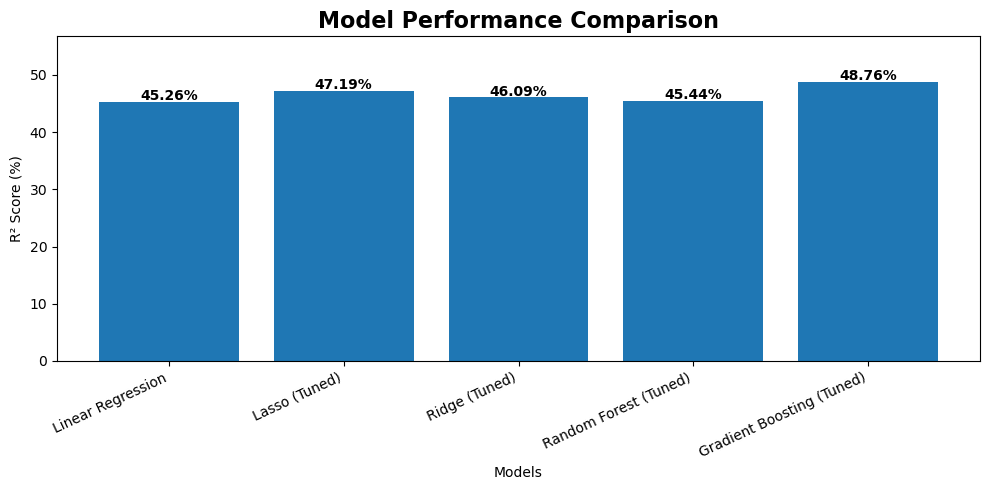

In [13]:
import matplotlib.pyplot as plt

# Create R² percentage values
plot_df = results_df.copy()

plot_df["R² Percentage"] = (
    plot_df["R² Score"] * 100
)

# Create bar chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["Model"],
    plot_df["R² Percentage"]
)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("R² Score (%)")
plt.xlabel("Models")

plt.xticks(
    rotation=25,
    ha="right"
)

# Show percentage on each bar
for bar, value in zip(
    bars,
    plot_df["R² Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(
    0,
    max(plot_df["R² Percentage"]) + 8
)

plt.tight_layout()

plt.show()

In [14]:
# =====================================================
# SAVE BEST MODEL
# =====================================================

best_model_name = best_model_row["Model"]

if best_model_name == "Gradient Boosting (Tuned)":
    final_model = best_gb

elif best_model_name == "Random Forest (Tuned)":
    final_model = best_rf

elif best_model_name == "Lasso (Tuned)":
    final_model = best_lasso

elif best_model_name == "Ridge (Tuned)":
    final_model = best_ridge

else:
    final_model = linear_model


print("🏆 Final Model:", best_model_name)

🏆 Final Model: Gradient Boosting (Tuned)


In [15]:
import joblib

joblib.dump(
    final_model,
    "diabetes_model.pkl"
)

print("✅ Final model saved as diabetes_model.pkl")

✅ Final model saved as diabetes_model.pkl


In [16]:
import os

print(os.path.abspath("diabetes_model.pkl"))
print(os.path.getsize("diabetes_model.pkl"), "bytes")

d:\Aenexz_internship\Aenexz_Internship\Diabetes_Streamlit_Project\diabetes_model.pkl
61724 bytes


In [17]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.datasets import load_diabetes


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Diabetes Progression Prediction",
    page_icon="🩺",
    layout="wide"
)


# =========================================================
# LOAD FINAL MODEL
# =========================================================

model = joblib.load("diabetes_model.pkl")


# =========================================================
# LOAD DATASET
# =========================================================

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

.main-title {
    font-size: 42px;
    font-weight: 800;
}

.subtitle {
    font-size: 18px;
    margin-bottom: 15px;
}

.tagline {
    background-color: #5427A8;
    padding: 10px 18px;
    border-radius: 12px;
    display: inline-block;
    font-size: 16px;
    font-weight: 600;
}

.section-title {
    font-size: 28px;
    font-weight: 700;
}

.info-card {
    padding: 20px;
    border-radius: 15px;
    text-align: center;
    border: 1px solid #444;
}

.baseline-card {
    padding: 20px;
    border-radius: 15px;
    border: 1px solid #D9534F;
}

.best-card {
    padding: 20px;
    border-radius: 15px;
    border: 1px solid #28A745;
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("🩺 Navigation")

page = st.sidebar.radio(
    "Explore Project",
    [
        "🏠 Home",
        "📊 Dataset Insights",
        "🔮 Prediction",
        "🏆 Model Performance"
    ]
)

st.sidebar.divider()

st.sidebar.write(
    "🧠 Machine Learning Regression"
)

st.sidebar.write(
    "🏆 Final Model: Gradient Boosting"
)


# =========================================================
# HOME
# =========================================================

if page == "🏠 Home":

    col1, col2 = st.columns([1.2, 1])

    with col1:

        st.markdown(
            '<div class="main-title">'
            '🩺 Diabetes Progression Prediction'
            '</div>',
            unsafe_allow_html=True
        )

        st.markdown(
            '<div class="subtitle">'
            'Smart Machine Learning Application for '
            'Predicting Diabetes Disease Progression'
            '</div>',
            unsafe_allow_html=True
        )

        st.markdown(
            '<div class="tagline">'
            '✨ Analyze • Optimize • Predict'
            '</div>',
            unsafe_allow_html=True
        )

    with col2:

        st.info(
            "🩺 Diabetes • Machine Learning • Prediction"
        )

    st.divider()


    # -----------------------------------------------------
    # PROJECT METRICS
    # -----------------------------------------------------

    col1, col2, col3 = st.columns(3)

    with col1:

        st.metric(
            "👥 Dataset Records",
            "442"
        )

    with col2:

        st.metric(
            "🧬 Input Features",
            "10"
        )

    with col3:

        st.metric(
            "🏆 Final Model",
            "Gradient Boosting"
        )


    st.write("")

    st.markdown(
        '<div class="section-title">'
        '🎯 Project Objective'
        '</div>',
        unsafe_allow_html=True
    )

    st.info(
        "Predict the quantitative diabetes disease-progression "
        "score using patient baseline features and machine "
        "learning regression techniques."
    )


    # -----------------------------------------------------
    # MODEL JOURNEY
    # -----------------------------------------------------

    st.markdown(
        '<div class="section-title">'
        '📈 Model Journey'
        '</div>',
        unsafe_allow_html=True
    )

    col1, col2 = st.columns(2)

    with col1:

        st.markdown(
            """
            <div class="baseline-card">

            ### 🔵 Baseline Model

            **Linear Regression**

            Simple and interpretable
            starting model.

            </div>
            """,
            unsafe_allow_html=True
        )

    with col2:

        st.markdown(
            """
            <div class="best-card">

            ### 🚀 Optimized Model

            **Gradient Boosting**

            Selected after hyperparameter
            tuning and model comparison.

            </div>
            """,
            unsafe_allow_html=True
        )


    st.write("")

    st.success(
        "🏆 The final model was selected based on the "
        "highest R² score from the model comparison."
    )


# =========================================================
# DATASET INSIGHTS
# =========================================================

elif page == "📊 Dataset Insights":

    st.title("📊 Dataset Insights")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("👥 Records", df.shape[0])

    with col2:
        st.metric("🧬 Features", 10)

    with col3:
        st.metric("🎯 Target", "Disease Progression")

    st.divider()

    st.subheader("🔍 Dataset Preview")

    st.dataframe(
        df.head(10),
        use_container_width=True
    )

    st.subheader("🧬 Feature Information")

    feature_info = pd.DataFrame({

        "Feature": [
            "age",
            "sex",
            "bmi",
            "bp",
            "s1",
            "s2",
            "s3",
            "s4",
            "s5",
            "s6"
        ],

        "Display Name": [
            "👤 Age",
            "⚧️ Sex",
            "⚖️ Body Mass Index",
            "❤️ Blood Pressure",
            "🧪 Total Cholesterol",
            "🧬 LDL",
            "💙 HDL",
            "📊 Cholesterol / HDL",
            "🧪 Triglycerides",
            "🩸 Blood Sugar"
        ]
    })

    st.dataframe(
        feature_info,
        use_container_width=True,
        hide_index=True
    )


# =========================================================
# PREDICTION
# =========================================================

elif page == "🔮 Prediction":

    st.title("🔮 Diabetes Progression Prediction")

    st.write(
        "Enter the feature values used by the trained "
        "machine learning model."
    )

    st.warning(
        "⚠️ The Scikit-learn Diabetes Dataset uses "
        "standardized feature values. Enter values using "
        "the same scaled format as the dataset."
    )

    st.divider()

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("👤 Patient Information")

        age = st.number_input(
            "👤 Age",
            value=0.0,
            format="%.5f"
        )

        sex = st.number_input(
            "⚧️ Sex",
            value=0.0,
            format="%.5f"
        )

        bmi = st.number_input(
            "⚖️ Body Mass Index",
            value=0.0,
            format="%.5f"
        )

        bp = st.number_input(
            "❤️ Blood Pressure",
            value=0.0,
            format="%.5f"
        )

        s1 = st.number_input(
            "🧪 Total Cholesterol (s1)",
            value=0.0,
            format="%.5f"
        )

    with col2:

        st.subheader("🧪 Blood Measurements")

        s2 = st.number_input(
            "🧬 LDL (s2)",
            value=0.0,
            format="%.5f"
        )

        s3 = st.number_input(
            "💙 HDL (s3)",
            value=0.0,
            format="%.5f"
        )

        s4 = st.number_input(
            "📊 Cholesterol / HDL (s4)",
            value=0.0,
            format="%.5f"
        )

        s5 = st.number_input(
            "🧪 Triglycerides (s5)",
            value=0.0,
            format="%.5f"
        )

        s6 = st.number_input(
            "🩸 Blood Sugar (s6)",
            value=0.0,
            format="%.5f"
        )


    st.divider()


    # -----------------------------------------------------
    # PREDICT
    # -----------------------------------------------------

    if st.button(
        "🚀 Generate Prediction",
        use_container_width=True
    ):

        input_data = pd.DataFrame(
            [[
                age,
                sex,
                bmi,
                bp,
                s1,
                s2,
                s3,
                s4,
                s5,
                s6
            ]],
            columns=[
                "age",
                "sex",
                "bmi",
                "bp",
                "s1",
                "s2",
                "s3",
                "s4",
                "s5",
                "s6"
            ]
        )

        prediction = model.predict(input_data)[0]

        st.success(
            "✅ Prediction Generated Successfully!"
        )

        col1, col2 = st.columns(2)

        with col1:

            st.metric(
                "🔮 Predicted Disease Progression",
                f"{prediction:.2f}"
            )

        with col2:

            st.metric(
                "🤖 Model Used",
                "Gradient Boosting"
            )

        st.info(
            "ℹ️ This application is intended for educational "
            "and machine-learning demonstration purposes "
            "and is not a medical diagnostic tool."
        )


# =========================================================
# MODEL PERFORMANCE
# =========================================================

elif page == "🏆 Model Performance":

    st.title("🏆 Model Performance")

    st.write(
        "Comparison of the machine learning models evaluated "
        "during the project."
    )

    st.success(
        "🏆 Final model selected from the highest R² score."
    )

    # Use the actual results created earlier
    results_df = pd.read_csv("model_results.csv")
    display_results = results_df.copy()

    display_results["R² Percentage"] = (
        display_results["R² Score"] * 100
    ).round(2).astype(str) + "%"

    st.subheader("📊 Model Comparison")

    st.dataframe(
        display_results,
        use_container_width=True,
        hide_index=True
    )

    st.subheader("📈 R² Score Comparison")

    chart_data = (
        results_df
        .set_index("Model")["R² Score"]
        * 100
    )

    st.bar_chart(chart_data)

    st.subheader("💡 Model Evaluation")

    st.write(
        """
        **R² Score:** Higher values indicate better
        explanatory performance.

        **MAE:** Lower values indicate smaller average
        prediction errors.

        **RMSE:** Lower values indicate better control
        over larger prediction errors.
        """
    )

Overwriting app.py


In [18]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("Model exists:", os.path.exists("diabetes_model.pkl"))

app.py exists: True
Model exists: True


In [19]:
with open("app.py", "r", encoding="utf-8") as f:
    app_code = f.read()

print(app_code[:1000])


import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.datasets import load_diabetes


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Diabetes Progression Prediction",
    page_icon="🩺",
    layout="wide"
)


# =========================================================
# LOAD FINAL MODEL
# =========================================================

model = joblib.load("diabetes_model.pkl")


# =========================================================
# LOAD DATASET
# =========================================================

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

.main-title {
    font-size: 42px;
    font-weight: 800;
}

.subtitle {
    font-siz

In [ ]:
!streamlit run app.py

In [ ]:
# Save model comparison results for Streamlit

results_df.to_csv(
    "model_results.csv",
    index=False
)

print("✅ Model results saved successfully!")

✅ Model results saved successfully!


In [ ]:
import os

print(os.path.exists("model_results.csv"))

True
